In [ ]:
# === Colab bootstrap: mount drive, clone/pull repo, link dataset ===
# Run this cell once after every Colab reconnect.
import os
from google.colab import drive, userdata

DATASET_DRIVE_PATH = '/content/drive/MyDrive/ml-final-project-data'
REPO_DIR = '/content/ml-final-project'

# 1. Mount Drive
if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')

# 2. Clone or pull repo
token = userdata.get('COLAB_ML_FINAL_PROJECT')
if not os.path.exists(REPO_DIR):
    os.chdir('/content')
    !git clone https://{token}@github.com/zong0728/ml-final-project.git
else:
    os.chdir(REPO_DIR)
    !git pull

os.chdir(REPO_DIR)

# 3. Symlink dataset from Drive
!ln -sfn "{DATASET_DRIVE_PATH}" "{REPO_DIR}/dataset"

# 4. Git identity (only needed if pushing from Colab)
!git config user.email "shengzhg@andrew.cmu.edu"
!git config user.name "Shengzhong Guan"

# 5. Embed token in remote so future git pull/push works without prompting
!git remote set-url origin https://{token}@github.com/zong0728/ml-final-project.git

print("✓ Repo ready at:", os.getcwd())
!ls -la dataset/ 2>&1 | head -5


# Power Outage Forecasting — Model Comparison Runner

This notebook runs **every registered model × every seed × {24h, 48h}** on the
Michigan outage dataset and logs results to `results/experiment_runs.csv`.

**Resumable**: if Colab disconnects, re-running the notebook picks up where it
left off (already-logged runs are skipped).

**Pipeline**:
1. Install deps
2. Locate project folder (Colab or local)
3. Dry-run schedule preview
4. Run all experiments (this is the overnight step)
5. Summary leaderboard + plots
6. Retrain best model on full data and write submission CSVs

You should only need to edit the `SEEDS` / `HORIZONS` / `MODELS_TO_RUN` cells if you want to restrict the run.

## 1. Install dependencies

In [1]:
!pip install -q xarray netCDF4 xgboost lightgbm statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.5 MB/s eta 0:00:00


## 2. Locate project root + put `src/` on the path

This cell auto-detects your setup. Expected layouts:
* **Local**: notebook sits at `<project>/run_experiments.ipynb` — nothing to do.
* **Colab (folder upload)**: upload the whole project folder to `/content/` (drag&drop or `!unzip`).
* **Colab (Drive mount)**: put the folder somewhere in `MyDrive`; this cell mounts Drive and searches for it.

In [2]:
import os, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

def find_project_root() -> Path:
    candidates = [Path.cwd()]
    if IN_COLAB:
        # Common upload locations
        candidates += [
            Path("/content/ml-final-project"),
            Path("/content/MLPS_Project"),
            Path("/content"),
        ]
        # Drive (mount lazily only if needed)
        from google.colab import drive
        if not Path("/content/drive").exists():
            drive.mount("/content/drive")
        for p in [
            Path("/content/drive/MyDrive/ml-final-project"),
            Path("/content/drive/MyDrive/MLPS_Project"),
        ]:
            candidates.append(p)
    for c in candidates:
        if (c / "dataset" / "data" / "train.nc").exists() and (c / "src").exists():
            return c.resolve()
    raise FileNotFoundError(
        "Could not locate project folder. Upload the full folder and make sure "
        "`dataset/data/train.nc` and `src/` both exist inside it."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")
print(f"CUDA available: ", end="")
import torch
print(torch.cuda.is_available(), "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Mounted at /content/drive
Project root: /content/drive/MyDrive/ml-final-project
CUDA available: True - NVIDIA A100-SXM4-80GB


## 3. Experiment configuration

Tune these if you want to restrict the sweep (e.g. for a quick smoke test).

In [3]:
from src import config
from src.runner import run_all
from src.registry import MODEL_REGISTRY
from src.training import summarize_runs

# ---- Sweep controls ----
SEEDS    = [42, 43, 44]   # 3 seeds for stochastic models; deterministic models run once
HORIZONS = [24, 48]
MODELS_TO_RUN = None      # None = all registered. Or pass a list: ["lstm", "dlinear"]

# Show what will be run
print(f"Registered models ({len(MODEL_REGISTRY)}):")
for name, info in MODEL_REGISTRY.items():
    flag = "stoch" if info.stochastic else "det  "
    print(f"  [{info.tier:9s}] [{flag}]  {name:16s}  {info.description}")

Registered models (20):
  [baseline ] [det  ]  zero              Predict zero for every county-hour.
  [baseline ] [det  ]  persistence       Repeat the last observed value for the whole horizon.
  [baseline ] [det  ]  seasonal_naive_24  ŷ[t+h] = y[t+h-24] — repeat yesterday's same hour.
  [baseline ] [det  ]  seasonal_naive_168  ŷ[t+h] = y[t+h-168] — repeat same hour last week.
  [baseline ] [det  ]  historical_mean   Per-(county, hour-of-day, day-of-week) historical mean.
  [classical] [det  ]  linreg_lag        LinearRegression on lag/rolling/weather features (log1p target).
  [classical] [det  ]  ridge_lag         Ridge(α=1.0) on lag/rolling/weather features (log1p target).
  [classical] [stoch]  xgboost           XGBoost regressor on lag features (log1p target).
  [classical] [stoch]  lightgbm          LightGBM regressor on lag features (log1p target).
  [classical] [det  ]  sarimax           Per-county SARIMAX(1,0,1) — classical time-series baseline.
  [neural   ] [stoch]  mlp   

## 4. Dry run — preview the schedule

In [4]:
_ = run_all(
    model_names=MODELS_TO_RUN,
    horizons=HORIZONS,
    seeds=SEEDS,
    dry_run=True,
)

[Runner] Scheduled 88 runs across 20 models, seeds=[42, 43, 44], horizons=[24, 48]
  DET    model=zero              seed=42  horizon=24
  DET    model=zero              seed=42  horizon=48
  DET    model=persistence       seed=42  horizon=24
  DET    model=persistence       seed=42  horizon=48
  DET    model=seasonal_naive_24  seed=42  horizon=24
  DET    model=seasonal_naive_24  seed=42  horizon=48
  DET    model=seasonal_naive_168  seed=42  horizon=24
  DET    model=seasonal_naive_168  seed=42  horizon=48
  DET    model=historical_mean   seed=42  horizon=24
  DET    model=historical_mean   seed=42  horizon=48
  DET    model=linreg_lag        seed=42  horizon=24
  DET    model=linreg_lag        seed=42  horizon=48
  DET    model=ridge_lag         seed=42  horizon=24
  DET    model=ridge_lag         seed=42  horizon=48
  STOCH  model=xgboost           seed=42  horizon=24
  STOCH  model=xgboost           seed=42  horizon=48
  STOCH  model=xgboost           seed=43  horizon=24
  STOCH  m

## 5. Run everything (the overnight cell)

Models run fast-to-slow-ish; each is logged to `results/experiment_runs.csv` as soon as it finishes. Safe to interrupt — just rerun and it resumes.

In [5]:
summary = run_all(
    model_names=MODELS_TO_RUN,
    horizons=HORIZONS,
    seeds=SEEDS,
    skip_on_error=True,   # don't let one bad model kill the whole night
)

[Runner] Scheduled 88 runs across 20 models, seeds=[42, 43, 44], horizons=[24, 48]

[  1/88] model=zero  seed=42  horizon=24h
-----------------------------------------
  val_rmse=43.6054  time=0.0s  total=0.0min

[  2/88] model=zero  seed=42  horizon=48h
-----------------------------------------
  val_rmse=70.4882  time=0.0s  total=0.0min

[  3/88] model=persistence  seed=42  horizon=24h
------------------------------------------------
  val_rmse=74.8750  time=0.0s  total=0.0min

[  4/88] model=persistence  seed=42  horizon=48h
------------------------------------------------
  val_rmse=108.2843  time=0.0s  total=0.0min

[  5/88] model=seasonal_naive_24  seed=42  horizon=24h
------------------------------------------------------
  val_rmse=263.3098  time=0.0s  total=0.0min

[  6/88] model=seasonal_naive_24  seed=42  horizon=48h
------------------------------------------------------
  val_rmse=291.1943  time=0.0s  total=0.0min

[  7/88] model=seasonal_naive_168  seed=42  horizon=24h
---

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.8892e-16): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


  val_rmse=1678.3584  time=1.4s  total=0.3min

[ 14/88] model=ridge_lag  seed=42  horizon=48h
----------------------------------------------
  val_rmse=1712.3666  time=23.4s  total=0.7min

[ 15/88] model=xgboost  seed=42  horizon=24h
--------------------------------------------
  val_rmse=27.6753  time=6.5s  total=0.8min

[ 16/88] model=xgboost  seed=42  horizon=48h
--------------------------------------------
  val_rmse=62.1363  time=10.1s  total=1.0min

[ 17/88] model=xgboost  seed=43  horizon=24h
--------------------------------------------
  val_rmse=34.1161  time=5.6s  total=1.1min

[ 18/88] model=xgboost  seed=43  horizon=48h
--------------------------------------------
  val_rmse=63.4371  time=10.4s  total=1.2min

[ 19/88] model=xgboost  seed=44  horizon=24h
--------------------------------------------
  val_rmse=28.5886  time=5.7s  total=1.3min

[ 20/88] model=xgboost  seed=44  horizon=48h
--------------------------------------------
  val_rmse=61.5475  time=10.1s  total=1.5min

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  val_rmse=39.4916  time=47.0s  total=2.3min

[ 22/88] model=lightgbm  seed=42  horizon=48h
---------------------------------------------


...

  val_rmse=98.5406  time=58.3s  total=49.6min

[ 87/88] model=itransformer  seed=44  horizon=24h
-------------------------------------------------


/content/drive/MyDrive/ml-final-project/src/models_sota.py:181: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


  val_rmse=66.5821  time=52.4s  total=50.5min

[ 88/88] model=itransformer  seed=44  horizon=48h
-------------------------------------------------


/content/drive/MyDrive/ml-final-project/src/models_sota.py:181: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


  val_rmse=81.3481  time=50.0s  total=51.3min

[Runner] Done. completed=82 skipped=0 errors=6 total_wall=51.3min


## 6. Leaderboard

In [6]:
import pandas as pd
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

leaderboard = summarize_runs()
leaderboard

,model,horizon,val_rmse_mean,val_rmse_std,val_rmse_min,val_rmse_max,n
0,xgboost,24,30.1267,3.4850,27.6753,34.1161,3
1,lightgbm,24,37.1353,3.5199,33.0891,39.4916,3
2,sarimax,24,40.2101,0.0000,40.2101,40.2101,1
3,bilstm,24,41.2803,3.9455,37.6797,45.4979,3
4,lstm,24,41.5828,3.5599,38.0560,45.1749,3
5,zero,24,43.6054,0.0000,43.6054,43.6054,1
6,linreg_lag,24,43.8135,0.0000,43.8135,43.8135,1
7,seasonal_naive_168,24,60.8949,0.0000,60.8949,60.8949,1
8,historical_mean,24,66.2680,0.0000,66.2680,66.2680,1
9,tcn,24,66.9328,3.7692,62.6804,69.8621,3


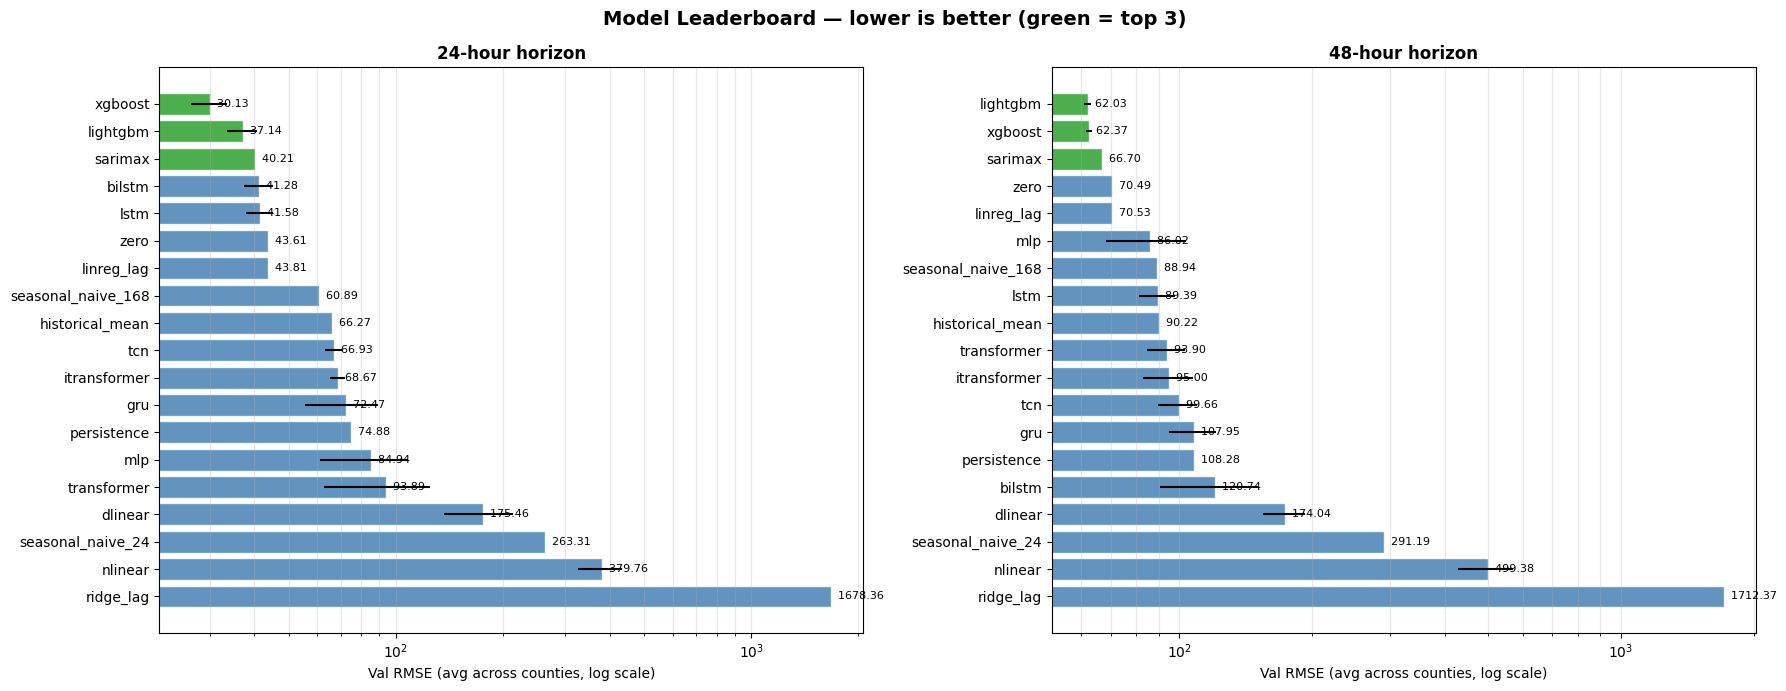

Saved figure to /content/drive/MyDrive/ml-final-project/results/figures/leaderboard.png


In [7]:
# Leaderboard plot — use log scale on x-axis so one blown-up model
# doesn't crush everything else into invisibility, and drop any model
# whose val_rmse is more than 100× the zero baseline (clearly broken).
import matplotlib.pyplot as plt
import numpy as np

SANITY_CAP_MULT = 100   # drop any model > 100× zero-baseline RMSE
USE_LOG_X = True        # log-scale x-axis to see all models at once

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)
for ax, h in zip(axes, HORIZONS):
    sub = leaderboard[leaderboard["horizon"] == h].copy().sort_values("val_rmse_mean")
    if sub.empty:
        continue

    # Drop clearly broken runs (e.g. log-target extrapolation explosion)
    zero_rmse = sub[sub["model"] == "zero"]["val_rmse_mean"]
    if len(zero_rmse):
        cap = float(zero_rmse.iloc[0]) * SANITY_CAP_MULT
        dropped = sub[sub["val_rmse_mean"] > cap]
        if len(dropped):
            print(f"[{h}h] dropped from plot (RMSE > {cap:.0f}): "
                  + ", ".join(f"{m}={v:.3g}" for m, v in zip(dropped['model'], dropped['val_rmse_mean'])))
        sub = sub[sub["val_rmse_mean"] <= cap]

    colors = ["tab:green" if i < 3 else "steelblue" for i in range(len(sub))]
    ax.barh(sub["model"], sub["val_rmse_mean"],
            xerr=sub["val_rmse_std"], color=colors, edgecolor="white", alpha=0.85)
    ax.invert_yaxis()
    if USE_LOG_X:
        ax.set_xscale("log")
    ax.set_xlabel("Val RMSE (avg across counties, log scale)" if USE_LOG_X else "Val RMSE")
    ax.set_title(f"{h}-hour horizon", fontweight="bold")
    ax.grid(True, axis="x", alpha=0.3, which="both")

    # Annotate each bar with the numeric value
    for y, v in enumerate(sub["val_rmse_mean"]):
        ax.text(v, y, f"  {v:.2f}", va="center", fontsize=8)

fig.suptitle("Model Leaderboard — lower is better (green = top 3)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "leaderboard.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved figure to {config.FIGURES_DIR / 'leaderboard.png'}")

## 7. Retrain best model on FULL train data and write submission CSVs

The comparison above used only `train[:-48h]`. For the actual submission we want
to retrain on the whole training set and predict the test-period timestamps.
Picks the best model per horizon by mean val RMSE.

In [8]:
from src.runner import retrain_best_on_full_and_predict_test
from src.training import best_model_per_horizon

best_by_h = best_model_per_horizon()
print("Best models per horizon (by mean val RMSE):")
for h, m in best_by_h.items():
    print(f"  {h}h → {m}")

# Write one submission per horizon using its best model
for h, m in best_by_h.items():
    retrain_best_on_full_and_predict_test(m, horizon=h, seed=42)

Best models per horizon (by mean val RMSE):
  24h → xgboost
  48h → lightgbm
[Final] xgboost@24h trained on full data in 16.7s — meta={'n_estimators': 500, 'max_depth': 6, 'lr': 0.05, 'log_target': True, 'origin_stride': 4}
[Final] wrote submission → /content/drive/MyDrive/ml-final-project/results/submissions/final_xgboost_pred_24h.csv
[Final] lightgbm@48h trained on full data in 85.7s — meta={'n_estimators': 800, 'num_leaves': 63, 'lr': 0.05, 'log_target': True, 'origin_stride': 4}
[Final] wrote submission → /content/drive/MyDrive/ml-final-project/results/submissions/final_lightgbm_pred_48h.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 8. (Optional) Narrow-down sweep for top-3 models

Once the broad comparison settles, uncomment and tune these cells to do a focused
hyperparameter sweep on the top 3 architectures. Edit `MODELS_TO_RUN` above and
crank `SEEDS` to e.g. `list(range(10))` for tighter std estimates.

In [9]:
# Example: only re-run the top-3 architectures on 10 seeds each for a final comparison.
# top3 = list(leaderboard.groupby("model")["val_rmse_mean"].mean().nsmallest(3).index)
# print("Focusing on:", top3)
# _ = run_all(model_names=top3, horizons=HORIZONS, seeds=list(range(10)))

## 9. Generator Pre-Positioning Policy (Part II)

Translate Part I predictions into the 5-county generator allocation required
by the problem. Implements the three-tier lexicographic greedy defined in
[`policy_methodology.md`](policy_methodology.md):

| Tier | Criterion | Trigger |
|------|-----------|---------|
| Primary | Expected marginal household-hours `E[Δ_c(k)]` (mean across 6-run ensemble) | Always |
| Secondary | Prediction stability `std[Δ_c(k)]` across ensemble (lower preferred) | Primary ties within 1% |
| Tertiary | Absolute `tracked[c]` (larger preferred) | Secondary also ties within 1% |

Outputs:
* Recommendation under the **default** (risk-neutral) tier hierarchy
* Robustness checks: 24h vs 48h, xgboost-only vs lightgbm-only, against null baselines
* `results/submissions/recommended_counties.txt` in the PDF-specified format


In [10]:
# ---- Greedy allocator (mirrors policy_methodology.md §4.2 and §5.1) ----
import numpy as np

def greedy_three_tier(pred_ensemble, tracked, capacity=1000, n_gen=5, tol=0.01):
    """Three-tier lexicographic greedy.

    Primary   : argmax mean marginal coverage across the ensemble.
    Secondary : min std of marginal coverage, when Primary ties within `tol`.
    Tertiary  : argmax tracked, when Secondary also ties.

    Parameters
    ----------
    pred_ensemble : (M, L, H) ndarray
    tracked       : (L,) ndarray
    Returns (assign, trace).
    """
    pred_ensemble = np.asarray(pred_ensemble, dtype=np.float64)
    tracked = np.asarray(tracked, dtype=np.float64)
    M, L, H = pred_ensemble.shape
    assert tracked.shape == (L,)

    assign = np.zeros(L, dtype=int)
    trace = []
    for step in range(n_gen):
        k_arr = assign[None, :, None]
        cov_now  = np.minimum(k_arr       * capacity, pred_ensemble).sum(axis=2)
        cov_next = np.minimum((k_arr + 1) * capacity, pred_ensemble).sum(axis=2)
        gains = cov_next - cov_now
        gain_mean = gains.mean(axis=0)
        gain_std  = gains.std(axis=0)

        top = gain_mean.max()
        tied_1 = np.where(gain_mean >= top * (1 - tol) - 1e-9)[0]
        if len(tied_1) == 1:
            best = int(tied_1[0]); tier = "primary"
        else:
            stds = gain_std[tied_1]
            min_std = stds.min()
            tied_2 = tied_1[stds <= min_std * (1 + tol) + 1e-9]
            if len(tied_2) == 1:
                best = int(tied_2[0]); tier = "secondary"
            else:
                best = int(tied_2[np.argmax(tracked[tied_2])]); tier = "tertiary"

        assign[best] += 1
        trace.append({
            "step": step + 1, "county_idx": best,
            "gain_mean": float(gain_mean[best]),
            "gain_std":  float(gain_std[best]),
            "tracked":   float(tracked[best]),
            "n_candidates_primary": len(tied_1),
            "tier_used": tier,
        })
    return assign, trace


def allocation_to_fips(assign, locations):
    return [locations[li] for li, k in enumerate(assign) for _ in range(int(k))]


def print_trace(trace, locations):
    for t in trace:
        print(f"  gen #{t['step']} -> {locations[t['county_idx']]}  "
              f"[tier={t['tier_used']}, n_prim_ties={t['n_candidates_primary']}]  "
              f"gain = {t['gain_mean']:>8,.0f} \u00b1 {t['gain_std']:>6,.0f}  "
              f"tracked = {t['tracked']:>9,.0f}")


In [11]:
# ---- Build ensemble of test predictions (3 seeds x 2 model families = 6) ----
# Each call retrains the model on the FULL training set (not just val-fit),
# then predicts the test-period timestamps. Total time ~3 min on A100.
import numpy as np
import xarray as xr
from src.runner import retrain_best_on_full_and_predict_test

ENSEMBLE_MODELS = ["xgboost", "lightgbm"]
ENSEMBLE_SEEDS  = [42, 43, 44]

ensemble = {}
for h in HORIZONS:
    stack = []
    for model in ENSEMBLE_MODELS:
        for seed in ENSEMBLE_SEEDS:
            preds = retrain_best_on_full_and_predict_test(model, horizon=h, seed=seed)
            stack.append(preds.T)  # (H, L) -> (L, H)
    ensemble[h] = np.stack(stack)  # (M, L, H)
    print(f"Horizon {h}h: ensemble shape = {ensemble[h].shape}")

# Tracked (tertiary signal) — time-mean since tracked is slowly varying.
ds_train_for_tracked = xr.open_dataset(config.TRAIN_PATH)
locations = [str(x) for x in ds_train_for_tracked.location.values]
tracked = ds_train_for_tracked.tracked.mean(dim="timestamp").values.astype(float)
print(f"tracked shape = {tracked.shape},  min = {tracked.min():.0f},  max = {tracked.max():.0f}")


[Final] xgboost@24h trained on full data in 16.6s — meta={'n_estimators': 500, 'max_depth': 6, 'lr': 0.05, 'log_target': True, 'origin_stride': 4}
[Final] wrote submission → /content/drive/MyDrive/ml-final-project/results/submissions/final_xgboost_pred_24h.csv
[Final] xgboost@24h trained on full data in 16.6s — meta={'n_estimators': 500, 'max_depth': 6, 'lr': 0.05, 'log_target': True, 'origin_stride': 4}
[Final] wrote submission → /content/drive/MyDrive/ml-final-project/results/submissions/final_xgboost_pred_24h.csv
[Final] xgboost@24h trained on full data in 16.7s — meta={'n_estimators': 500, 'max_depth': 6, 'lr': 0.05, 'log_target': True, 'origin_stride': 4}
[Final] wrote submission → /content/drive/MyDrive/ml-final-project/results/submissions/final_xgboost_pred_24h.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[Final] lightgbm@24h trained on full data in 43.0s — meta={'n_estimators': 800, 'num_leaves': 63, 'lr': 0.05, 'log_target': True, 'origin_stride': 4}
[Final] wrote submission → /content/drive/MyDrive/ml-final-project/results/submissions/final_lightgbm_pred_24h.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[Final] lightgbm@24h trained on full data in 44.5s — meta={'n_estimators': 800, 'num_leaves': 63, 'lr': 0.05, 'log_target': True, 'origin_stride': 4}
[Final] wrote submission → /content/drive/MyDrive/ml-final-project/results/submissions/final_lightgbm_pred_24h.csv


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[Final] lightgbm@48h trained on full data in 85.2s — meta={'n_estimators': 800, 'num_leaves': 63, 'lr': 0.05, 'log_target': True, 'origin_stride': 4}
[Final] wrote submission → /content/drive/MyDrive/ml-final-project/results/submissions/final_lightgbm_pred_48h.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[Final] lightgbm@48h trained on full data in 78.6s — meta={'n_estimators': 800, 'num_leaves': 63, 'lr': 0.05, 'log_target': True, 'origin_stride': 4}
[Final] wrote submission → /content/drive/MyDrive/ml-final-project/results/submissions/final_lightgbm_pred_48h.csv
[Final] lightgbm@48h trained on full data in 79.5s — meta={'n_estimators': 800, 'num_leaves': 63, 'lr': 0.05, 'log_target': True, 'origin_stride': 4}
[Final] wrote submission → /content/drive/MyDrive/ml-final-project/results/submissions/final_lightgbm_pred_48h.csv
Horizon 48h: ensemble shape = (6, 83, 48)
tracked shape = (83,),  min = 2122,  max = 922425


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [12]:
# ---- Primary recommendation: 48h horizon, full 6-model ensemble ----
PRIMARY_HORIZON = 48
pred_ensemble = ensemble[PRIMARY_HORIZON]

assign, trace = greedy_three_tier(
    pred_ensemble=pred_ensemble,
    tracked=tracked,
    capacity=1000, n_gen=5, tol=0.01,
)

print(f"=== Primary recommendation ({PRIMARY_HORIZON}h horizon, full ensemble) ===")
print_trace(trace, locations)
fips_final = allocation_to_fips(assign, locations)
total_exp  = sum(t["gain_mean"] for t in trace)
print(f"\nRecommended counties: {fips_final}")
print(f"Expected total household-hours served: {total_exp:,.0f}")


=== Primary recommendation (48h horizon, full ensemble) ===
  gen #1 -> 26163  [tier=primary, n_prim_ties=1]  gain =   34,059 ±  6,242  tracked =   922,425
  gen #2 -> 26125  [tier=primary, n_prim_ties=1]  gain =   20,535 ±  3,565  tracked =   618,067
  gen #3 -> 26161  [tier=primary, n_prim_ties=1]  gain =    4,079 ±  1,027  tracked =   174,443
  gen #4 -> 26099  [tier=primary, n_prim_ties=1]  gain =    3,450 ±    428  tracked =   413,676
  gen #5 -> 26163  [tier=primary, n_prim_ties=1]  gain =    2,349 ±  3,881  tracked =   922,425

Recommended counties: ['26099', '26125', '26161', '26163', '26163']
Expected total household-hours served: 64,472


In [13]:
# ---- Robustness: run the allocator under variant configurations ----
import pandas as pd

configs = {
    "default_48h_full_ensemble": (ensemble[48], tracked),
    "24h_horizon_full_ensemble": (ensemble[24], tracked),
    "48h_xgboost_only":          (ensemble[48][:len(ENSEMBLE_SEEDS)], tracked),
    "48h_lightgbm_only":         (ensemble[48][len(ENSEMBLE_SEEDS):], tracked),
}

rows = []
all_picks = {}
for name, (pe, tr) in configs.items():
    a, _t = greedy_three_tier(pe, tr, capacity=1000, n_gen=5, tol=0.01)
    picks = allocation_to_fips(a, locations)
    all_picks[name] = picks
    rows.append({"config": name, "recommendation": picks,
                 "n_unique_counties": len(set(picks))})
robust_df = pd.DataFrame(rows)
print("=== Robustness table ===")
print(robust_df.to_string(index=False))

# Overlap matrix: how many counties do any two configs share (with multiplicity)?
print("\n=== Pairwise overlap (count of shared FIPS slots, max 5) ===")
names = list(all_picks.keys())
M = pd.DataFrame(index=names, columns=names, dtype=int)
for a in names:
    for b in names:
        # Use Counter-style intersection to respect multiplicity.
        from collections import Counter
        ca, cb = Counter(all_picks[a]), Counter(all_picks[b])
        M.loc[a, b] = sum((ca & cb).values())
print(M.to_string())


=== Robustness table ===
                   config                      recommendation  n_unique_counties
default_48h_full_ensemble [26099, 26125, 26161, 26163, 26163]                  4
24h_horizon_full_ensemble [26099, 26123, 26125, 26163, 26163]                  4
         48h_xgboost_only [26099, 26125, 26161, 26163, 26163]                  4
        48h_lightgbm_only [26081, 26099, 26125, 26161, 26163]                  5

=== Pairwise overlap (count of shared FIPS slots, max 5) ===
                           default_48h_full_ensemble  24h_horizon_full_ensemble  48h_xgboost_only  48h_lightgbm_only
default_48h_full_ensemble                        5.0                        4.0               5.0                4.0
24h_horizon_full_ensemble                        4.0                        5.0               4.0                3.0
48h_xgboost_only                                 5.0                        4.0               5.0                4.0
48h_lightgbm_only                       

In [14]:
# ---- Null-policy comparisons (report-defensive baselines) ----
# Does our prediction-driven policy actually beat simple heuristics on the val split?
from collections import Counter

# Use val-period ground truth (last 48h of train) as the evaluation window
ds_val_trust = xr.open_dataset(config.TRAIN_PATH)
out_val = ds_val_trust.out.transpose("location", "timestamp").values[:, -PRIMARY_HORIZON:]  # (L, H)

def total_served(fips_list, truth_window):
    """Given a list of FIPS assignments and (L, H) ground truth, return hh-hours served."""
    cnt = Counter(fips_list)
    total = 0.0
    for fips, k in cnt.items():
        li = locations.index(fips)
        total += np.minimum(k * 1000, truth_window[li]).sum()
    return float(total)

# Three baseline policies:
hist_total = ds_val_trust.out.transpose("location", "timestamp").values.sum(axis=1)

policies = {
    "our_policy (pred-driven, 3-tier)": fips_final,
    "population-only (top-5 tracked)":   [locations[i] for i in np.argsort(-tracked)[:5]],
    "historical-only (top-5 hist total)":[locations[i] for i in np.argsort(-hist_total)[:5]],
    "random-sample":                     list(np.random.RandomState(42).choice(locations, 5, replace=False)),
}

print("=== Policy comparison on val-window ground truth ===")
print(f"{'policy':40s}  {'hh-hours served':>15s}  recommendation")
for name, picks in policies.items():
    served = total_served(picks, out_val)
    print(f"{name:40s}  {served:>15,.0f}  {picks}")


=== Policy comparison on val-window ground truth ===
policy                                    hh-hours served  recommendation
our_policy (pred-driven, 3-tier)                   79,400  ['26099', '26125', '26161', '26163', '26163']
population-only (top-5 tracked)                    61,865  ['26163', '26125', '26099', '26081', '26049']
historical-only (top-5 hist total)                 65,566  ['26125', '26163', '26099', '26161', '26081']
random-sample                                       3,960  [np.str_('26061'), np.str_('26001'), np.str_('26045'), np.str_('26063'), np.str_('26037')]


In [15]:
# ---- Write the recommended_counties.txt submission file ----
submission_path = config.SUBMISSIONS_DIR / "recommended_counties.txt"
with open(submission_path, "w") as f:
    f.write(f"[{', '.join(fips_final)}]\n")
print(f"Wrote {submission_path}")
print(f"Contents: [{', '.join(fips_final)}]")


Wrote /content/drive/MyDrive/ml-final-project/results/submissions/recommended_counties.txt
Contents: [26099, 26125, 26161, 26163, 26163]


## 10. Auto-release the Colab runtime (stop burning A100 credits)

Once everything above finishes, this cell releases the GPU so you stop paying for idle compute while asleep.

* **60-second grace countdown** first — interrupt the cell (■ / `Ctrl-M I`) to cancel if you're still iterating.
* Uses the official [`google.colab.runtime.unassign()`](https://colab.research.google.com/notebooks/pro.ipynb) — disconnects **and** releases the runtime (which is what frees your Colab Pro compute units). `!kill -9 -1` only disconnects; the runtime can keep billing until its idle timeout.
* Set `AUTO_SHUTDOWN = False` if you want to keep the session after completion.

> Run this cell with **Run All**, not manually. If you Run All from the top, the countdown only fires after all upstream experiments finish.


In [16]:
AUTO_SHUTDOWN = True
GRACE_SECONDS = 60
# Where to copy results/ before shutdown (only used if project isn't already in Drive).
# Change this if you want a different Drive location.
DRIVE_BACKUP_PARENT = "/content/drive/MyDrive"

# ---- 1. Final sanity print ----
try:
    from src.training import summarize_runs
    print("=== Final leaderboard ===")
    print(summarize_runs().to_string(index=False))
    print()
    print("Saved under results/:")
    for p in sorted(config.RESULTS_DIR.rglob("*")):
        if p.is_file():
            sz = p.stat().st_size
            print(f"  {p.relative_to(config.RESULTS_DIR)}  ({sz/1024:.1f} KB)")
except Exception as e:
    print(f"summary failed: {e}")

# ---- 2. Back up results to Drive if the project lives on the ephemeral VM ----
IS_COLAB = "google.colab" in sys.modules
project_on_drive = str(PROJECT_ROOT).startswith("/content/drive/")
backup_dest = None
if IS_COLAB and not project_on_drive:
    import shutil, datetime
    # Ensure Drive is mounted
    if not Path("/content/drive").exists():
        from google.colab import drive as _drive
        _drive.mount("/content/drive")
    stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    backup_dest = Path(DRIVE_BACKUP_PARENT) / f"ml-final-project-results_{stamp}"
    print(f"\nCopying results/ → {backup_dest} (so they survive shutdown)...")
    shutil.copytree(config.RESULTS_DIR, backup_dest)
    print(f"✓ Backup complete: {backup_dest}")
elif IS_COLAB and project_on_drive:
    print(f"\nProject already lives under Drive ({PROJECT_ROOT}) — results/ is persistent, no backup needed.")

# ---- 3. Shutdown with grace period ----
if AUTO_SHUTDOWN and IS_COLAB:
    import time
    print()
    for i in range(GRACE_SECONDS, 0, -1):
        print(f"\rShutting down in {i:3d}s ... interrupt this cell to cancel.", end="", flush=True)
        time.sleep(1)
    print()
    if backup_dest is not None:
        print(f"Results backed up at: {backup_dest}")
    print("Releasing runtime via google.colab.runtime.unassign() ...")
    from google.colab import runtime
    runtime.unassign()
else:
    print("\nAuto-shutdown skipped (not in Colab, or AUTO_SHUTDOWN=False).")


=== Final leaderboard ===
             model  horizon  val_rmse_mean  val_rmse_std  val_rmse_min  val_rmse_max  n
           xgboost       24        30.1267        3.4850       27.6753       34.1161  3
          lightgbm       24        37.1353        3.5199       33.0891       39.4916  3
           sarimax       24        40.2101        0.0000       40.2101       40.2101  1
            bilstm       24        41.2803        3.9455       37.6797       45.4979  3
              lstm       24        41.5828        3.5599       38.0560       45.1749  3
              zero       24        43.6054        0.0000       43.6054       43.6054  1
        linreg_lag       24        43.8135        0.0000       43.8135       43.8135  1
seasonal_naive_168       24        60.8949        0.0000       60.8949       60.8949  1
   historical_mean       24        66.2680        0.0000       66.2680       66.2680  1
               tcn       24        66.9328        3.7692       62.6804       69.8621  3
      